In [1]:
import snntorch as snn
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import minmax_scale
import copy
import os 

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
class Net(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs, num_steps=25, beta=0.95, thres=0.75):
        super().__init__()
        self.num_steps = num_steps
        
        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, threshold=thres, learn_beta=False, learn_threshold=False)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, threshold=thres, learn_beta=False, learn_threshold=False)

    def forward(self, x):
        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        spk2_rec = []
        mem2_rec = []

        for step in range(self.num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

In [9]:

def cross_validation(x, y, net_kwargs, num_folds=10, num_epochs=1, loss_type='spk', iter_count=1000):
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1)
    acc_hist, prec_hist, rec_hist, f1_hist = [], [], [], []
    loss_fn = nn.CrossEntropyLoss()
    
    # --- Tracking the Best Fold ---
    best_acc = -1.0
    best_model = None
    best_x_train, best_y_train = None, None
    best_x_val, best_y_val = None, None

    for fold, (train_indices, val_indices) in enumerate(kf.split(x, y)):
        print(f"Fold {fold + 1}/{num_folds}")
        torch.manual_seed(0)

        net = Net(**net_kwargs).to(device)
        optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))
        
        x_train, y_train = x[train_indices].to(device), y[train_indices].to(device)
        x_val, y_val = x[val_indices], y[val_indices] # Keeping validation sets default (CPU usually)
        batch_size = len(x_train)

        net.train()
        for epoch in range(num_epochs):
            for tt in range(iter_count):
                spk_rec, mem_rec = net(x_train.view(batch_size, -1))

                loss_val = torch.zeros((1), dtype=dtype, device=device)
                for step in range(net_kwargs['num_steps']):
                    if loss_type == 'spk':
                        loss_val += loss_fn(spk_rec[step], y_train)
                    else:
                        loss_val += loss_fn(mem_rec[step], y_train)

                optimizer.zero_grad()
                loss_val.backward()
                optimizer.step()
                    
        test_loader = DataLoader(list(zip(x_val, y_val)), batch_size=len(x_val), shuffle=False)
        predicted_hist, targets_hist = [], []
        
        net.eval()
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(device), targets.to(device)
                test_spk, _ = net(data.view(data.size(0), -1))

                _, predicted = test_spk.sum(dim=0).max(1)
                predicted_hist.extend(predicted.cpu().numpy())
                targets_hist.extend(targets.cpu().numpy())
        
        acc = accuracy_score(targets_hist, predicted_hist)
        prec = precision_score(targets_hist, predicted_hist, zero_division=0)
        rec = recall_score(targets_hist, predicted_hist, zero_division=0)
        f1 = f1_score(targets_hist, predicted_hist, zero_division=0)

        acc_hist.append(round(acc, 4))
        prec_hist.append(round(prec, 4))
        rec_hist.append(round(rec, 4))
        f1_hist.append(round(f1, 4))
        
        # --- Update Best Model and Data based on Accuracy ---
        if acc > best_acc:
            best_acc = acc
            # Deepcopy ensures we save the weights at this exact moment
            best_model = copy.deepcopy(net)
            # Clone and move to CPU to prevent GPU memory bloat over 10 folds
            best_x_train = x_train.clone().cpu()
            best_y_train = y_train.clone().cpu()
            best_x_val = x_val.clone().cpu()
            best_y_val = y_val.clone().cpu()
            
        print(f"Fold Accuracy: {acc:.4f} | Best Accuracy So Far: {best_acc:.4f}")
        print("=" * 30)

    # Return the best components instead of the last ones
    return acc_hist, prec_hist, rec_hist, f1_hist, best_model, best_x_train, best_y_train, best_x_val, best_y_val


In [ ]:
# ==========================================
# Data Processing & Pipeline
# ==========================================
def evaluate_classification(dat_org, pos_label, neg_label, thres, enc, loss):
    print(f"\n--- Running Classification: {pos_label} vs {neg_label} (enc: {enc}, loss: {loss}) ---")
    dat = dat_org.loc[dat_org.label.isin([pos_label, neg_label])].reset_index(drop=True)
    dat['case'] = [1 if ('f' in str(i)) else 0 for i in dat['case']]

    df_x_data = dat.drop(['label', 'case'], axis=1, errors='ignore')
    df_y_data = dat['label']

    ndf_x_data = df_x_data.copy()
    ndf_x_data[:] = minmax_scale(ndf_x_data)
    lsize = round(max(ndf_x_data.max()) * 100)
    
    data_train = []
    
    for row in range(len(ndf_x_data)):
        raw_f = ndf_x_data.iloc[row].tolist()
        if enc == 'raw':
            subdat = [val for val in raw_f]
        elif enc == 'dot':
            subdat = [[0 if (i%2==0) and (i < val*200) else 1 for i in range(lsize*2) ] for val in raw_f]
        else: 
            subdat = [[1 if (i < val * 100) else 0 for i in range(lsize)] for val in raw_f]
        data_train.append([subdat])

    targets_train = [0 if (i == pos_label) else 1 for i in df_y_data.tolist()]

    data_train = torch.tensor(data_train, dtype=torch.float)
    targets_train = torch.tensor(targets_train, dtype=torch.int64)

    num_inputs_calculated = data_train[0].numel() 

    net_kwargs = {
        'num_inputs': num_inputs_calculated,
        'num_hidden': num_inputs_calculated * 1,
        'num_outputs': 2,
        'num_steps': 25,
        'beta': 0.95,
        'thres': thres
    }

    # Unpack the new return values including train datasets
    acc, prec, rec, f1, best_model, best_x_train, best_y_train, best_x_val, best_y_val = cross_validation(
        data_train, targets_train, net_kwargs, num_folds=10, num_epochs=1, loss_type=loss, iter_count=1000
    )

    print("\nCV Average Results:")
    print([round(np.mean(acc), 4), round(np.mean(prec), 4), round(np.mean(rec), 4), round(np.mean(f1), 4)])

    save_dir = "best_fold_data"
    os.makedirs(save_dir, exist_ok=True)
    
    torch.save(best_x_train, os.path.join(save_dir, f"{pos_label}_{neg_label}_x_train.pt"))
    torch.save(best_y_train, os.path.join(save_dir, f"{pos_label}_{neg_label}_y_train.pt"))
    torch.save(best_x_val, os.path.join(save_dir, f"{pos_label}_{neg_label}_x_val.pt"))
    torch.save(best_y_val, os.path.join(save_dir, f"{pos_label}_{neg_label}_y_val.pt"))
    torch.save(best_model.state_dict(), os.path.join(save_dir, f"{pos_label}_{neg_label}_model.pth"))
    

    # Return the datasets along with the model
    return best_model, best_x_train, best_y_train, best_x_val, best_y_val, net_kwargs


## 1. Import data and train a model

In [ ]:
# data: single_20.csv  /  interact_20.csv  / integrate_20.csv
# enc: raw / dot / solid
# loss: mem / spk
dat_org = pd.read_csv('.\\datasets\\integrate_20.csv') 

In [13]:
# 2.1 Intimacy vs non_Intimacy
best_model, best_x_train, best_y_train, best_x_val, best_y_val, net_kwargs = evaluate_classification(dat_org, 'Intimacy', 'non_Intimacy', 
                                                                                                     thres=0.75, enc='solid', loss='spk')


--- Running Classification: Intimacy vs non_Intimacy (enc: solid, loss: spk) ---
Fold 1/10
Fold Accuracy: 0.9319 | Best Accuracy So Far: 0.9319
Fold 2/10
Fold Accuracy: 0.9512 | Best Accuracy So Far: 0.9512
Fold 3/10
Fold Accuracy: 0.9434 | Best Accuracy So Far: 0.9512
Fold 4/10
Fold Accuracy: 0.9383 | Best Accuracy So Far: 0.9512
Fold 5/10
Fold Accuracy: 0.9267 | Best Accuracy So Far: 0.9512
Fold 6/10
Fold Accuracy: 0.9460 | Best Accuracy So Far: 0.9512
Fold 7/10
Fold Accuracy: 0.9319 | Best Accuracy So Far: 0.9512
Fold 8/10
Fold Accuracy: 0.9332 | Best Accuracy So Far: 0.9512
Fold 9/10
Fold Accuracy: 0.9242 | Best Accuracy So Far: 0.9512
Fold 10/10
Fold Accuracy: 0.9383 | Best Accuracy So Far: 0.9512

CV Average Results:
[np.float64(0.9365), np.float64(0.9339), np.float64(0.9317), np.float64(0.9327)]
최고 성능의 폴드 데이터와 모델이 'best_fold_data/' 폴더에 저장되었습니다.


In [14]:
# 2.2 Empathy vs non_Empathy
best_model, best_x_train, best_y_train, best_x_val, best_y_val, net_kwargs = evaluate_classification(dat_org, 'Empathy', 'non_Empathy',
                                                                                                     thres=0.75, enc='solid', loss='spk')


--- Running Classification: Empathy vs non_Empathy (enc: solid, loss: spk) ---
Fold 1/10
Fold Accuracy: 0.9436 | Best Accuracy So Far: 0.9436
Fold 2/10
Fold Accuracy: 0.9656 | Best Accuracy So Far: 0.9656
Fold 3/10
Fold Accuracy: 0.9362 | Best Accuracy So Far: 0.9656
Fold 4/10
Fold Accuracy: 0.9362 | Best Accuracy So Far: 0.9656
Fold 5/10
Fold Accuracy: 0.9436 | Best Accuracy So Far: 0.9656
Fold 6/10
Fold Accuracy: 0.9521 | Best Accuracy So Far: 0.9656
Fold 7/10
Fold Accuracy: 0.9521 | Best Accuracy So Far: 0.9656
Fold 8/10
Fold Accuracy: 0.9607 | Best Accuracy So Far: 0.9656
Fold 9/10
Fold Accuracy: 0.9423 | Best Accuracy So Far: 0.9656
Fold 10/10
Fold Accuracy: 0.9386 | Best Accuracy So Far: 0.9656

CV Average Results:
[np.float64(0.9471), np.float64(0.9486), np.float64(0.9514), np.float64(0.9499)]
최고 성능의 폴드 데이터와 모델이 'best_fold_data/' 폴더에 저장되었습니다.


In [15]:
# 2.3 Competition vs Cooperation
best_model, best_x_train, best_y_train, best_x_val, best_y_val, net_kwargs = evaluate_classification(dat_org, 'Competition', 'Cooperation', 
                                                                                                     thres=0.75, enc='solid', loss='spk')


--- Running Classification: Competition vs Cooperation (enc: solid, loss: spk) ---
Fold 1/10
Fold Accuracy: 0.9595 | Best Accuracy So Far: 0.9595
Fold 2/10
Fold Accuracy: 0.9527 | Best Accuracy So Far: 0.9595
Fold 3/10
Fold Accuracy: 0.9510 | Best Accuracy So Far: 0.9595
Fold 4/10
Fold Accuracy: 0.9645 | Best Accuracy So Far: 0.9645
Fold 5/10
Fold Accuracy: 0.9527 | Best Accuracy So Far: 0.9645
Fold 6/10
Fold Accuracy: 0.9560 | Best Accuracy So Far: 0.9645
Fold 7/10
Fold Accuracy: 0.9586 | Best Accuracy So Far: 0.9645
Fold 8/10
Fold Accuracy: 0.9476 | Best Accuracy So Far: 0.9645
Fold 9/10
Fold Accuracy: 0.9628 | Best Accuracy So Far: 0.9645
Fold 10/10
Fold Accuracy: 0.9510 | Best Accuracy So Far: 0.9645

CV Average Results:
[np.float64(0.9556), np.float64(0.9556), np.float64(0.9597), np.float64(0.9576)]
최고 성능의 폴드 데이터와 모델이 'best_fold_data/' 폴더에 저장되었습니다.


In [16]:
# 2.4 High Focus vs Low Focus
best_model, best_x_train, best_y_train, best_x_val, best_y_val, net_kwargs = evaluate_classification(dat_org, 'High Focus', 'Low Focus', 
                                                                                                     thres=0.75, enc='solid', loss='spk')


--- Running Classification: High Focus vs Low Focus (enc: solid, loss: spk) ---
Fold 1/10
Fold Accuracy: 0.9516 | Best Accuracy So Far: 0.9516
Fold 2/10
Fold Accuracy: 0.9397 | Best Accuracy So Far: 0.9516
Fold 3/10
Fold Accuracy: 0.9516 | Best Accuracy So Far: 0.9516
Fold 4/10
Fold Accuracy: 0.9412 | Best Accuracy So Far: 0.9516
Fold 5/10
Fold Accuracy: 0.9553 | Best Accuracy So Far: 0.9553
Fold 6/10
Fold Accuracy: 0.9568 | Best Accuracy So Far: 0.9568
Fold 7/10
Fold Accuracy: 0.9449 | Best Accuracy So Far: 0.9568
Fold 8/10
Fold Accuracy: 0.9516 | Best Accuracy So Far: 0.9568
Fold 9/10
Fold Accuracy: 0.9546 | Best Accuracy So Far: 0.9568
Fold 10/10
Fold Accuracy: 0.9523 | Best Accuracy So Far: 0.9568

CV Average Results:
[np.float64(0.95), np.float64(0.9469), np.float64(0.9511), np.float64(0.9489)]
최고 성능의 폴드 데이터와 모델이 'best_fold_data/' 폴더에 저장되었습니다.


## Hyperparameter evaluation

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.preprocessing import minmax_scale

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
rcParams['axes.linewidth'] = 1.2
rcParams['font.size'] = 11
rcParams['axes.titlesize'] = 14
rcParams['axes.labelsize'] = 12
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11
rcParams['legend.fontsize'] = 11
rcParams['figure.dpi'] = 300 # 고해상도 출력

def prepare_data(dat_org, pos_label, neg_label):
    dat = dat_org.loc[dat_org.label.isin([pos_label, neg_label])].reset_index(drop=True)
    dat['case'] = [1 if ('f' in str(i)) else 0 for i in dat['case']]
    
    df_x_data = dat.drop(['label', 'case'], axis=1, errors='ignore')
    df_y_data = dat['label']
    
    ndf_x_data = df_x_data.copy()
    ndf_x_data[:] = minmax_scale(ndf_x_data)
    lsize = round(max(ndf_x_data.max()) * 100)
    
    data_train = []
    for row in range(len(ndf_x_data)):
        raw_f = ndf_x_data.iloc[row].tolist()
        subdat = [[1 if (i < val * 100) else 0 for i in range(lsize)] for val in raw_f]
        data_train.append([subdat])
        
    targets_train = [0 if (i == pos_label) else 1 for i in df_y_data.tolist()]
    
    data_train = torch.tensor(data_train, dtype=torch.float)
    targets_train = torch.tensor(targets_train, dtype=torch.int64)
    
    return data_train, targets_train

# (Task Name, Pos Label, Neg Label, Threshold)
tasks = [
    ('Intimacy', 'Intimacy', 'non_Intimacy', 0.75),
    ('Empathy', 'Empathy', 'non_Empathy', 0.75),
    ('Competition', 'Competition', 'Cooperation', 1.00),
    ('Focus', 'High Focus', 'Low Focus', 1.00)
]

hidden_nodes_list = [64, 128, 256, 512, 1000]
time_steps_list = [10, 15, 20, 25, 30]

all_grid_results = []


In [ ]:

for task_name, pos, neg, thres in tasks:
    print(f"\n=========================================")
    print(f"[{task_name}] Task...")
    
    data_train, targets_train = prepare_data(dat_org, pos, neg)
    in_features = data_train[0].numel() 
    
    for hidden in hidden_nodes_list:
        for steps in time_steps_list:
            print(f"  > TRAIN START: Hidden={hidden}, Steps={steps}...", end=" ")
            
            net_kwargs = {
                'num_inputs': in_features,
                'num_hidden': hidden,
                'num_outputs': 2,
                'num_steps': steps,
                'beta': 0.95,
                'thres': thres
            }
            
            acc, prec, rec, f1, _, _, _, _, _ = cross_validation(
                data_train, targets_train, net_kwargs, 
                num_folds=5, num_epochs=1, loss_type='spk', iter_count=1000
            )
            
            mean_acc, mean_f1 = np.mean(acc), np.mean(f1)
            all_grid_results.append({
                'Task': task_name,
                'Hidden Nodes': hidden,
                'Time Steps': steps,
                'Accuracy': mean_acc,
                'F1 Score': mean_f1
            })
            print(f"COMPLETE! (Acc: {mean_acc:.4f}, F1: {mean_f1:.4f})")

df_all = pd.DataFrame(all_grid_results)


In [40]:
df_all = df_all.loc[df_all[df_all.columns[2]] <30]


📊 Accuracy 히트맵 생성 중...


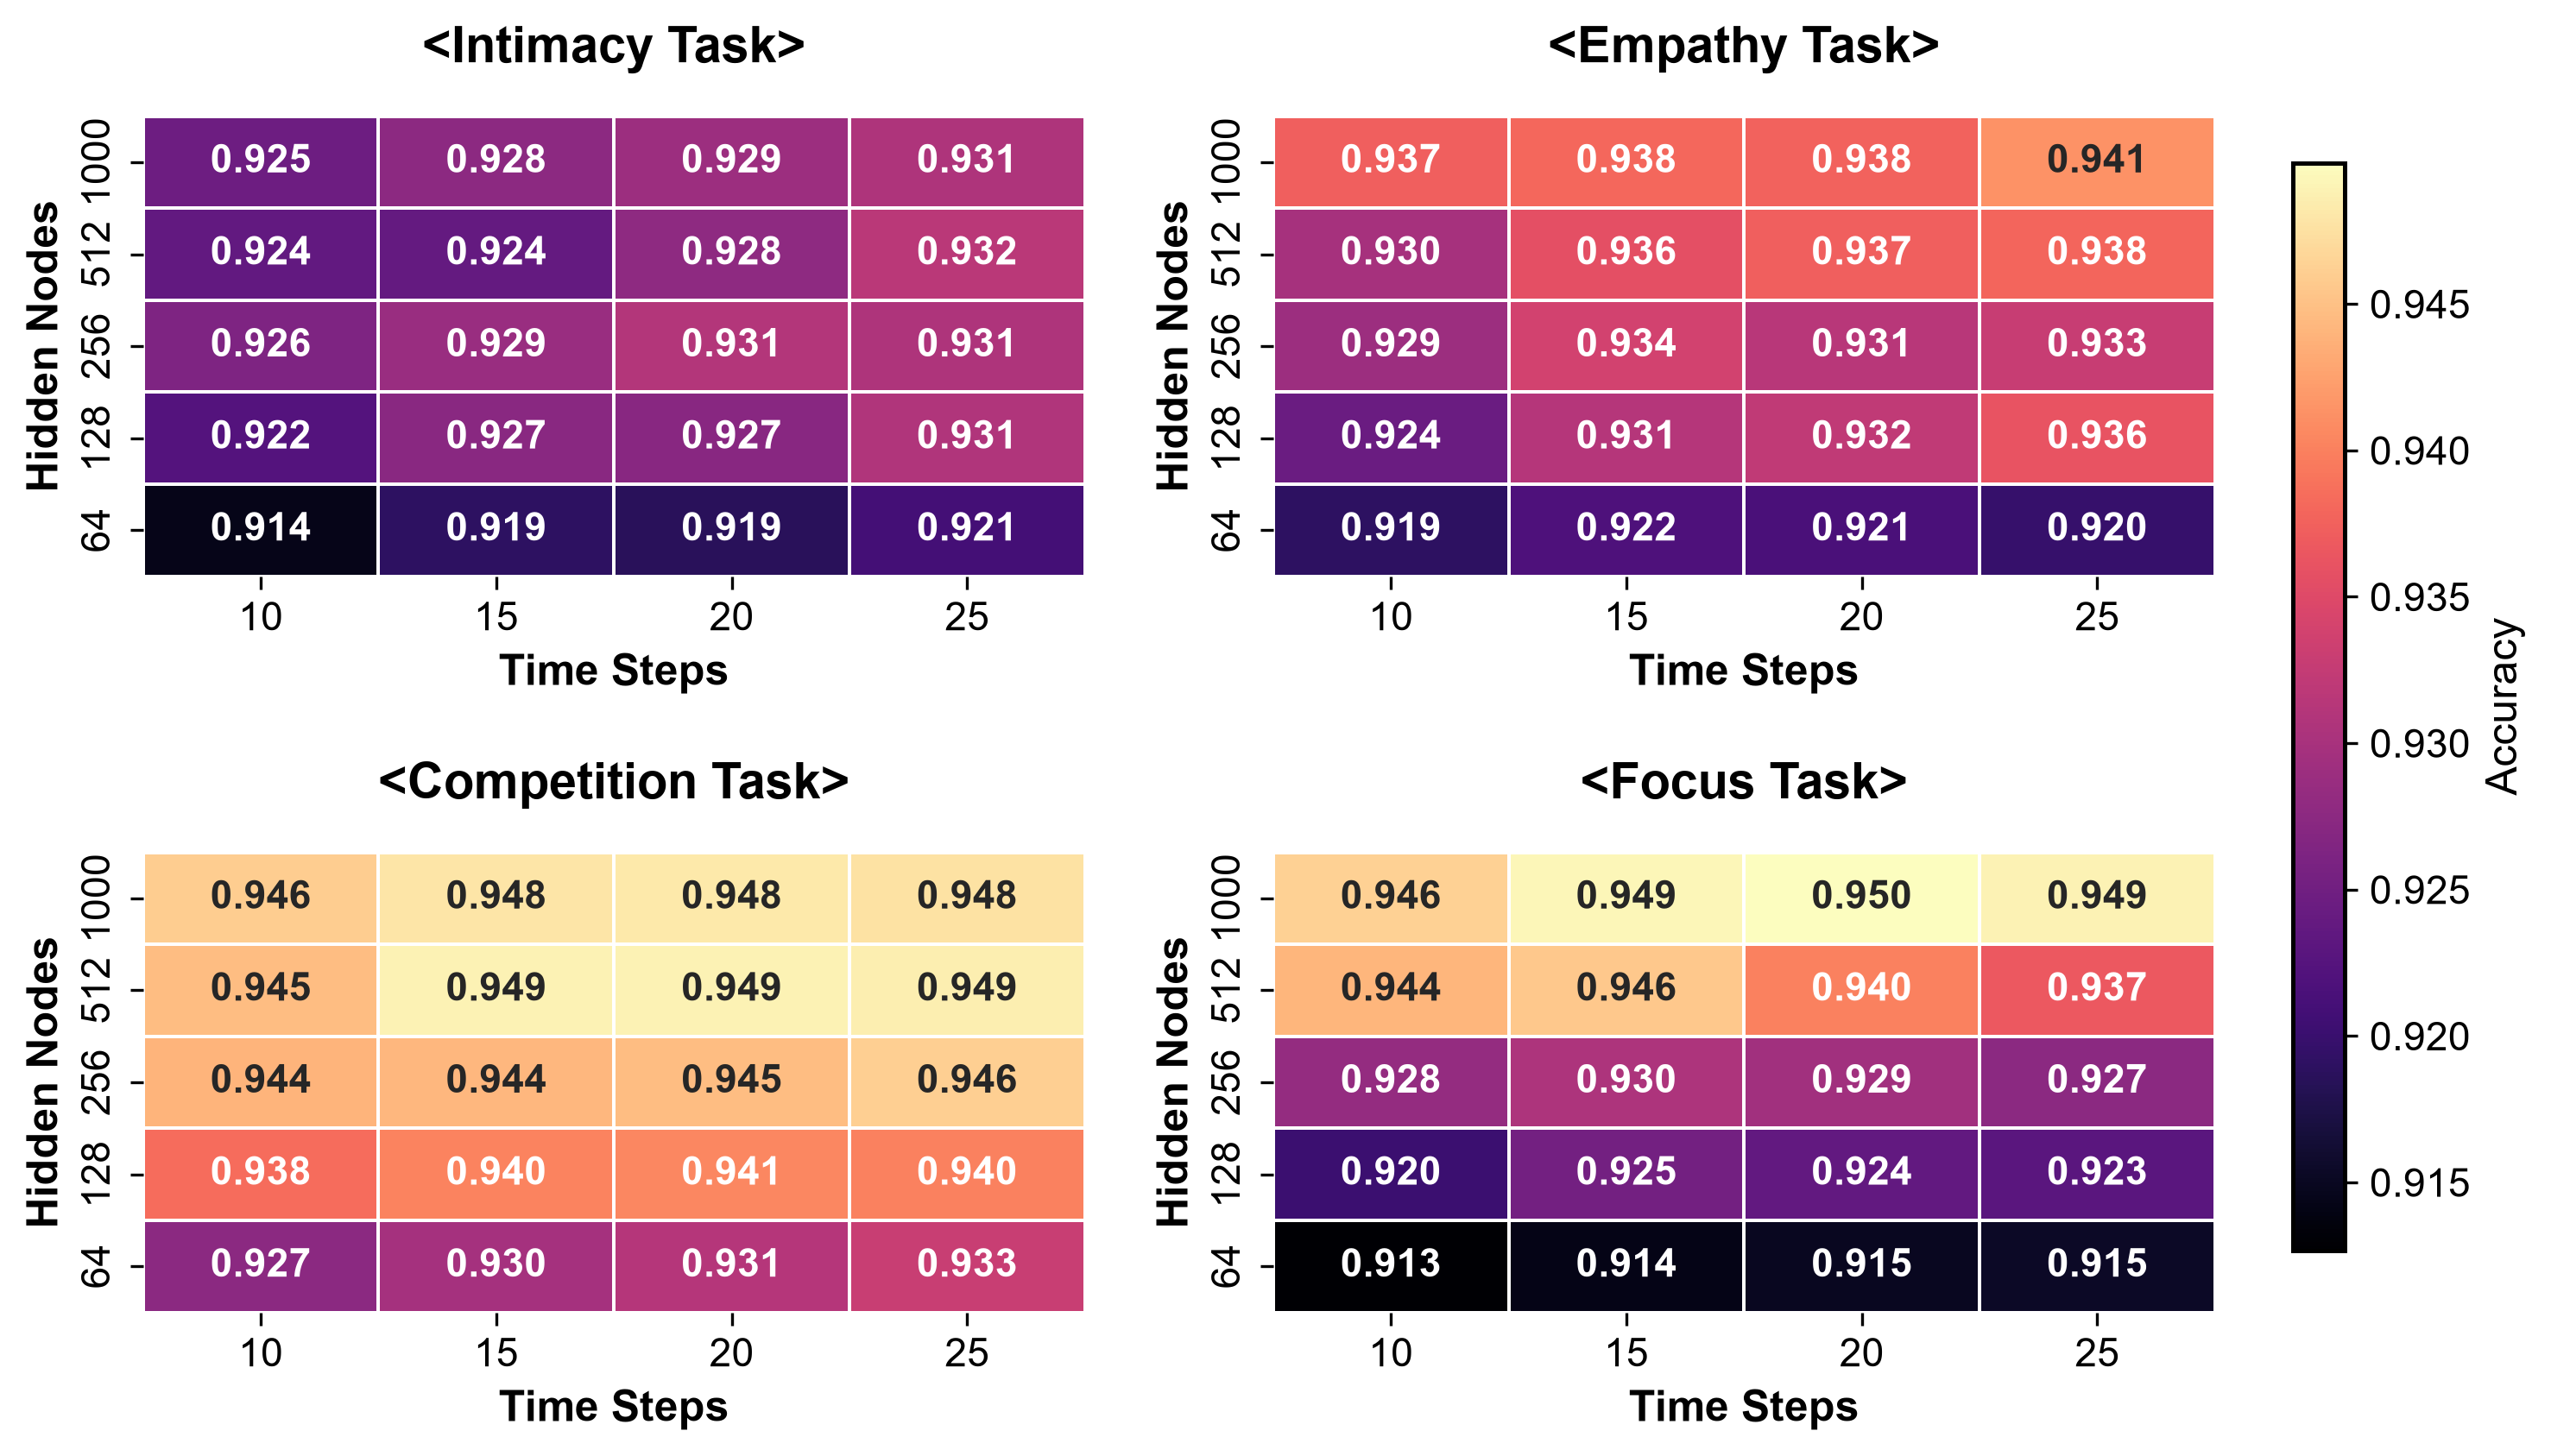

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_journal_heatmaps(df, metric, cmap, filename):
    vmin = df[metric].min()
    vmax = df[metric].max()

    fig, axes = plt.subplots(2, 2, figsize=(10, 6)) 
    axes = axes.flatten()
    
    for idx, (task_name, _, _, _) in enumerate(tasks):
        ax = axes[idx]
        
        df_task = df[df['Task'] == task_name]
        pivot_data = df_task.pivot(index='Hidden Nodes', columns='Time Steps', values=metric)
        
        sns.heatmap(pivot_data, annot=True, fmt=".3f", cmap=cmap,
                    vmin=vmin, vmax=vmax, cbar=False,  
                    ax=ax, annot_kws={"size": 11, "weight": "bold"},
                    linewidths=0.5, linecolor='white')
        
        ax.set_title(f'<{task_name} Task>', fontweight='bold', pad=15)
        ax.set_xlabel('Time Steps', fontweight='bold')
        ax.set_ylabel('Hidden Nodes', fontweight='bold')
        ax.invert_yaxis()
          
    plt.subplots_adjust(left=0.05, right=0.85, wspace=0.2, hspace=0.6)

    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) 

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([]) 
    fig.colorbar(sm, cax=cbar_ax, label=metric)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()

plot_journal_heatmaps(df_all, metric='Accuracy', cmap='magma', filename='SNN_Accuracy_Grid.pdf')


📊 F1 Score 히트맵 생성 중...


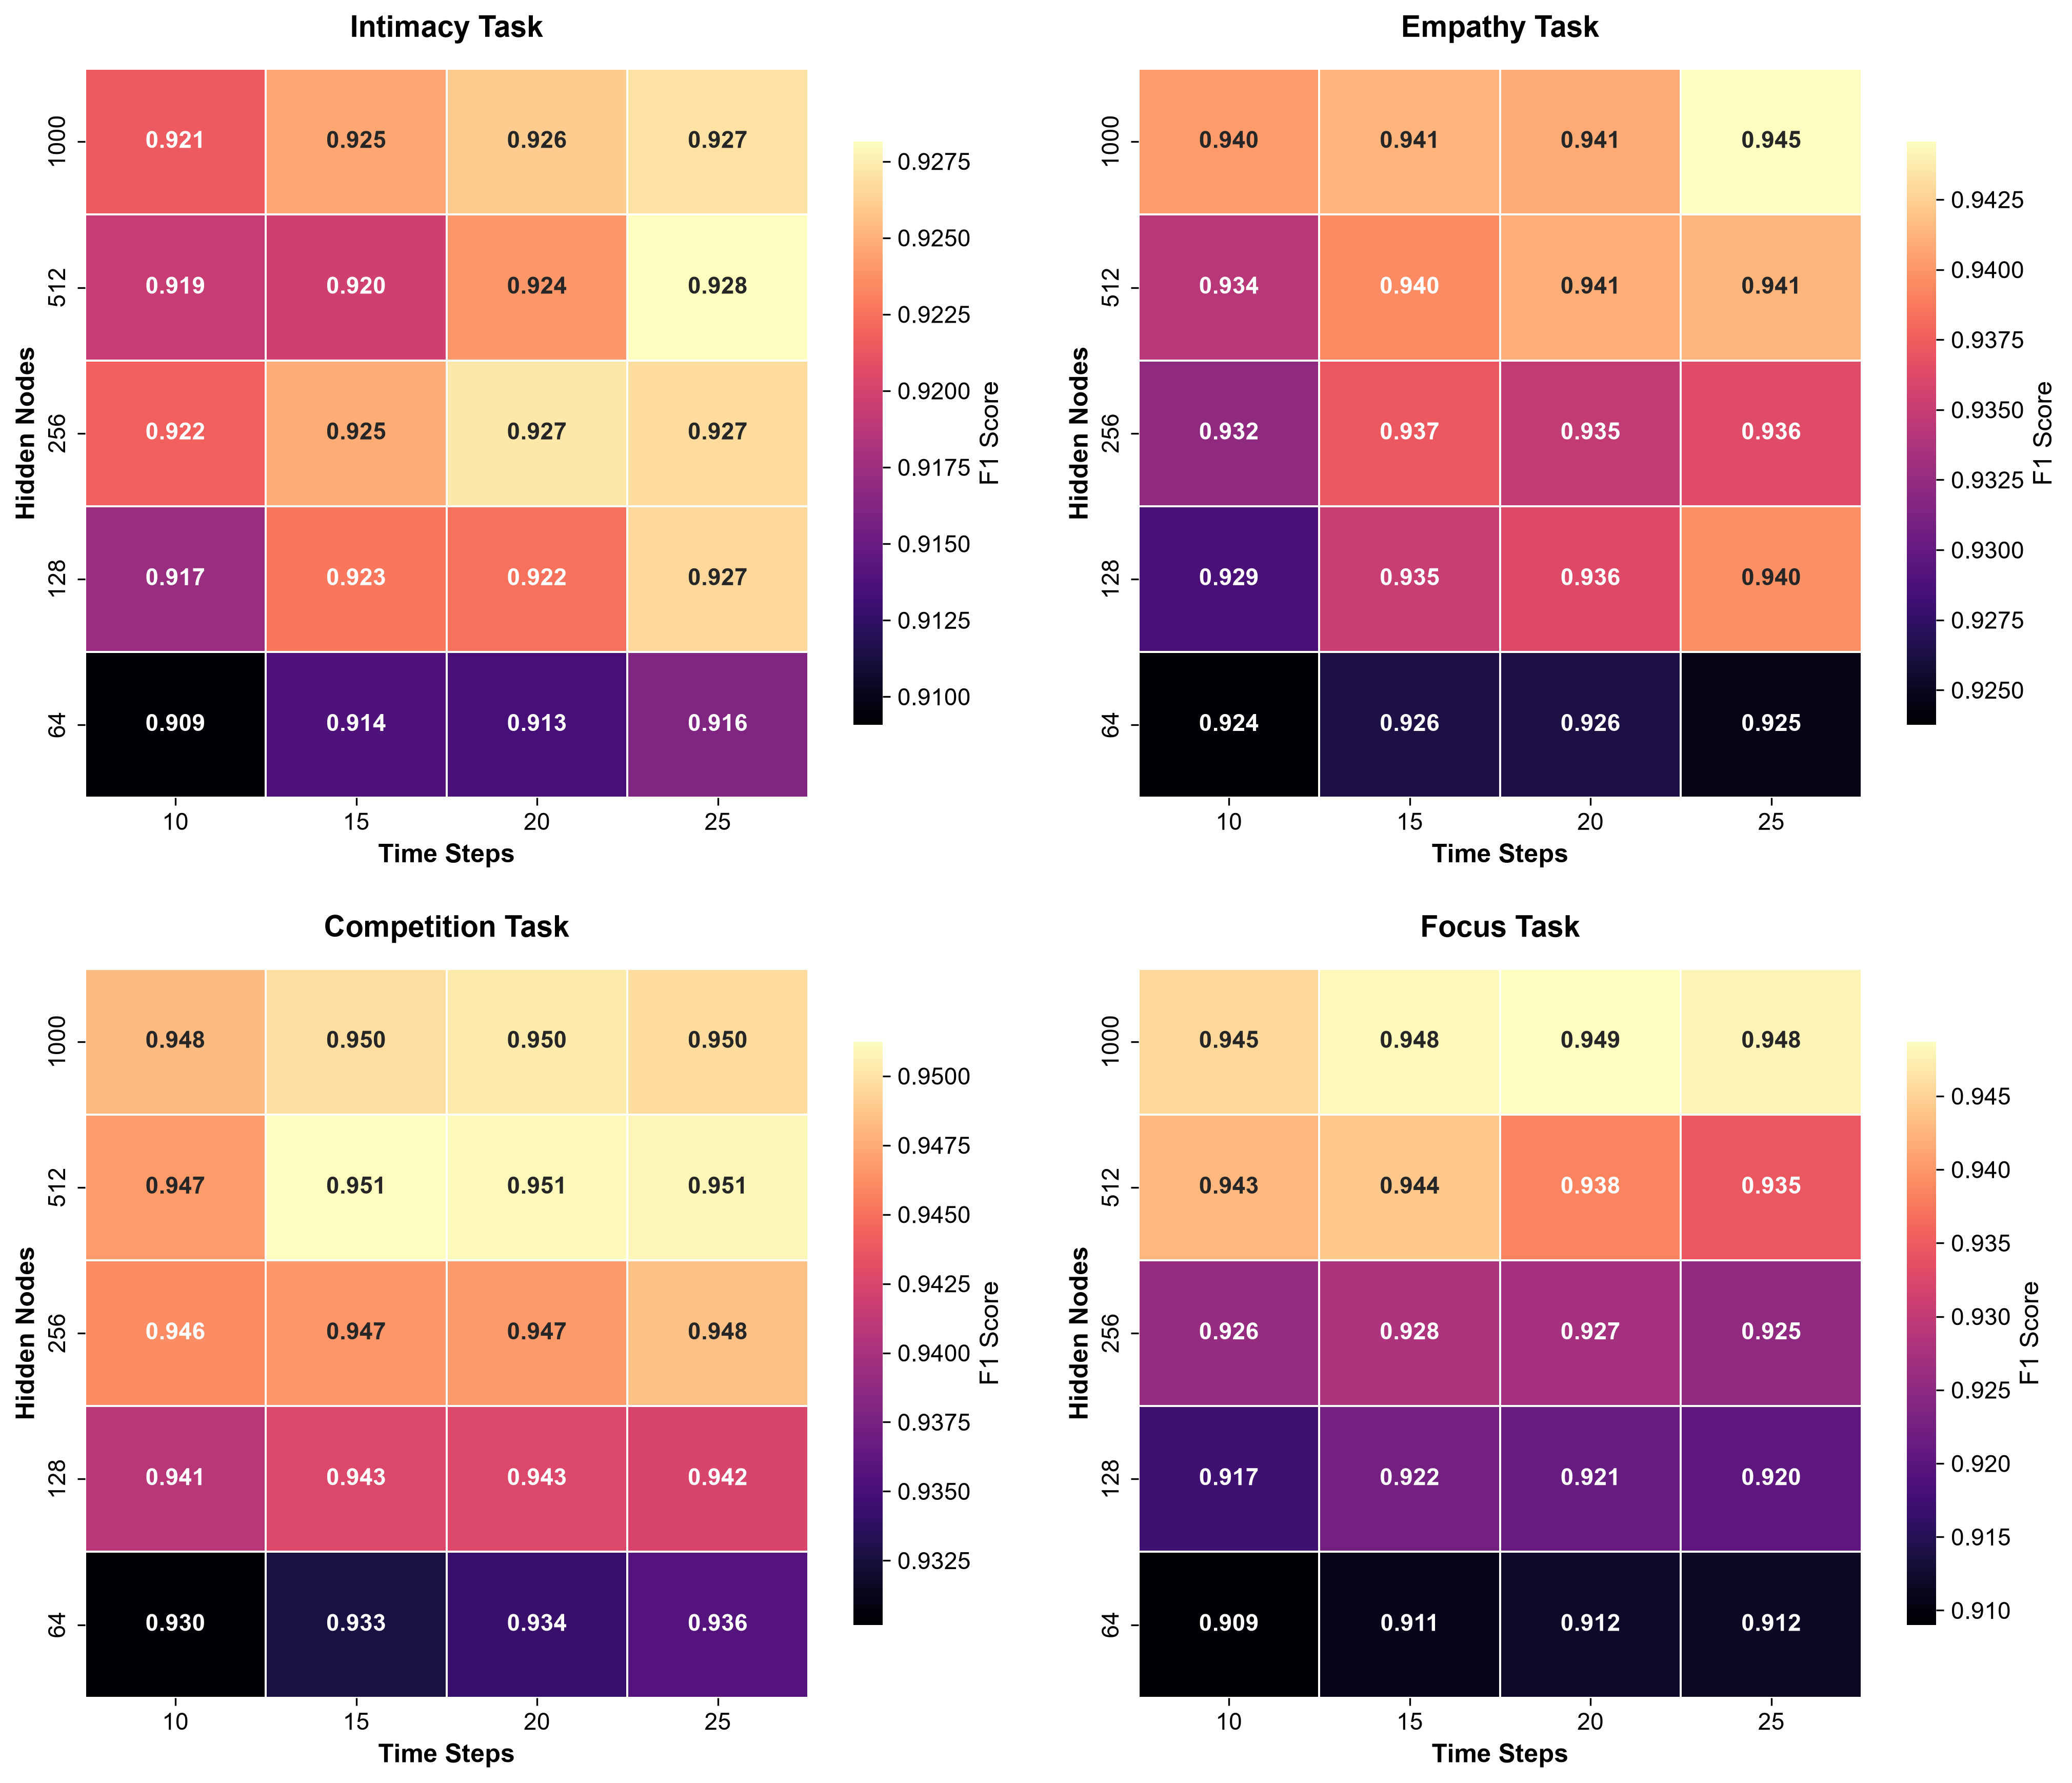

In [ ]:
# [B] F1 Score 2x2 
plot_journal_heatmaps(df_all, metric='F1 Score', cmap='magma', filename='SNN_F1_Grid.pdf')